# 💻 Laptop Price Predictor — End-to-End ML Pipeline

> **Author:** Malla Sujith Vaishnav  
> **Domain:** E-Commerce / Consumer Electronics  
> **Tools:** Python · Pandas · Scikit-learn · XGBoost · Matplotlib · Seaborn  
> **Deployment:** Streamlit Web App

---
### Pipeline Overview
```
Raw Data → Data Cleaning → Feature Engineering → EDA → 
Model Training → Model Evaluation → Best Model Export → Deployment
```

---

## Stage 1 — Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE   = 'Set2'
FIG_SIZE  = (14, 5)
ACCENT    = '#4C72B0'

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, ExtraTreesRegressor,
    VotingRegressor, StackingRegressor
)
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print('All libraries loaded successfully.')
print(f'   NumPy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')

All libraries loaded successfully.
   NumPy   : 1.26.3
   Pandas  : 2.1.4


---
## Stage 2 — Data Loading & Initial Inspection

In [2]:
dataset = pd.read_csv('data\laptop_data.csv')

dataset.drop(columns=[c for c in dataset.columns if 'Unnamed' in c], inplace=True)

print(f'Shape  : {dataset.shape[0]:,} rows × {dataset.shape[1]} columns')
print(f'Memory : {dataset.memory_usage(deep=True).sum() / 1024:.1f} KB')
dataset.head()

Shape  : 1,303 rows × 11 columns
Memory : 720.4 KB


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   object 
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
dtypes: float64(2), object(9)
memory usage: 112.1+ KB


In [4]:
dataset.describe().T.style.background_gradient(cmap='Blues').format(precision=2)

,count,mean,std,min,25%,50%,75%,max
Inches,1303.00,15.02,1.43,10.10,14.00,15.60,15.60,18.40
Price,1303.00,59870.04,37243.20,9270.72,31914.72,52054.56,79274.25,324954.72


In [5]:
missing = dataset.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print('No missing values found in the dataset.')
else:
    print('Missing values detected:')
    display(missing.to_frame('Missing Count'))

No missing values found in the dataset.


---
## Stage 3 — Feature Engineering

The raw dataset contains several columns that are stored as free-text strings but encode multiple structured signals. We extract those signals systematically.

### 3.1 — Screen Resolution → Touchscreen Flag + PPI + HD Flag

In [6]:
dataset['Touchscreen'] = dataset['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

dataset['HD'] = dataset['ScreenResolution'].apply(lambda x: 1 if 'HD' in x else 0)

res = dataset['ScreenResolution'].str.split('x', n=1, expand=True)
res[0] = res[1].str.replace(',', '').str.findall(r'(\d+\.?\d+)').apply(lambda x: x[0])
res[0] = res[0].astype(int)
res[1] = res[1].astype(int)

dataset['Inches']  = dataset['Inches'].astype(float)
dataset['PPI']     = ((res[0]**2 + res[1]**2)**0.5 / dataset['Inches']).round(2)

dataset.drop(columns=['ScreenResolution'], inplace=True)

print('Screen features extracted: Touchscreen, HD, PPI')
dataset[['Touchscreen', 'HD', 'PPI']].describe().T

Screen features extracted: Touchscreen, HD, PPI


,count,mean,std,min,25%,50%,75%,max
Touchscreen,1303.0,0.147352,0.354593,0.00,0.00,0.00,0.0,1.00
HD,1303.0,0.702993,0.457115,0.00,0.00,1.00,1.0,1.00
PPI,1303.0,102.082141,30.673190,62.78,88.29,97.91,109.1,244.38


### 3.2 — CPU String → CPU Brand Category

In [7]:
def categorise_cpu(cpu_str):
    name = ' '.join(cpu_str.split()[:3])
    if name in ('Intel Core i7', 'Intel Core i5', 'Intel Core i3'):
        return name
    elif cpu_str.split()[0] == 'Intel':
        return 'Other Intel Processor'
    else:
        return 'AMD Processor'

dataset['Cpu brand'] = dataset['Cpu'].apply(categorise_cpu)
dataset.drop(columns=['Cpu'], inplace=True)

print('CPU Brand Distribution')
print(dataset['Cpu brand'].value_counts().to_string())

CPU Brand Distribution
Cpu brand
Intel Core i7            527
Intel Core i5            423
Other Intel Processor    154
Intel Core i3            136
AMD Processor             63


### 3.3 — Memory String → Structured Storage Columns

In [8]:
def parse_storage(storage_str):
    d = {'Flash Storage': 0, 'Hybrid': 0, 'SSD': 0, 'HDD': 0}
    s = storage_str.lower().strip()
    digits = int(''.join(filter(str.isdigit, s)) or 0)
    if 'tb' in s:
        digits *= 1024
    if   'flash' in s:  d['Flash Storage'] = digits
    elif 'hybrid' in s: d['Hybrid']        = digits
    elif 'ssd' in s:    d['SSD']           = digits
    elif 'hdd' in s:    d['HDD']           = digits
    return d

storage_split = dataset['Memory'].str.split(r'\+', expand=True).fillna('0')

primary   = storage_split[0].apply(lambda x: pd.Series(parse_storage(x)))
secondary = storage_split[1].apply(lambda x: pd.Series(parse_storage(x)))[['Hybrid', 'SSD', 'HDD']]

primary.columns   = [f'Primary {c}'   for c in primary.columns]
secondary.columns = [f'Secondary {c}' for c in secondary.columns]

dataset = pd.concat([dataset, primary, secondary], axis=1)
dataset.drop(columns=['Memory'], inplace=True)

print('Storage columns created:')
print([c for c in dataset.columns if 'Primary' in c or 'Secondary' in c])

Storage columns created:
['Primary Flash Storage', 'Primary Hybrid', 'Primary SSD', 'Primary HDD', 'Secondary Hybrid', 'Secondary SSD', 'Secondary HDD']


### 3.4 — Clean Numeric Columns & Encode Categoricals

In [9]:
dataset['Ram']    = dataset['Ram'].str.replace('GB', '').astype(int)
dataset['Weight'] = dataset['Weight'].str.replace('kg', '').astype(float)

dataset['Gpu brand'] = dataset['Gpu'].apply(lambda x: x.split()[0])
dataset = dataset[dataset['Gpu brand'] != 'ARM']          # drop rare outlier
dataset.drop(columns=['Gpu'], inplace=True)

lab = LabelEncoder()
cat_cols = ['Company', 'TypeName', 'OpSys', 'Cpu brand', 'Gpu brand']
for col in cat_cols:
    dataset[col] = lab.fit_transform(dataset[col])

print(f'Final dataset shape: {dataset.shape}')
dataset.head()

Final dataset shape: (1302, 19)


,Company,TypeName,Inches,Ram,OpSys,Weight,Price,Touchscreen,HD,PPI,Cpu brand,Primary Flash Storage,Primary Hybrid,Primary SSD,Primary HDD,Secondary Hybrid,Secondary SSD,Secondary HDD,Gpu brand
0,1,4,13.3,8,8,1.37,71378.6832,0,0,170.13,2,0,0,128,0,0,0,0,1
1,1,4,13.3,8,8,1.34,47895.5232,0,0,95.70,2,128,0,0,0,0,0,0,1
2,7,3,15.6,8,4,1.86,30636.0000,0,1,97.91,2,0,0,256,0,0,0,0,1
3,1,4,15.4,16,8,1.83,135195.3360,0,0,165.30,3,0,0,512,0,0,0,0,0
4,1,4,13.3,8,8,1.37,96095.8080,0,0,170.13,2,0,0,256,0,0,0,0,1


---
## Stage 4 — Exploratory Data Analysis (EDA)

### 4.1 — Target Distribution: Laptop Price

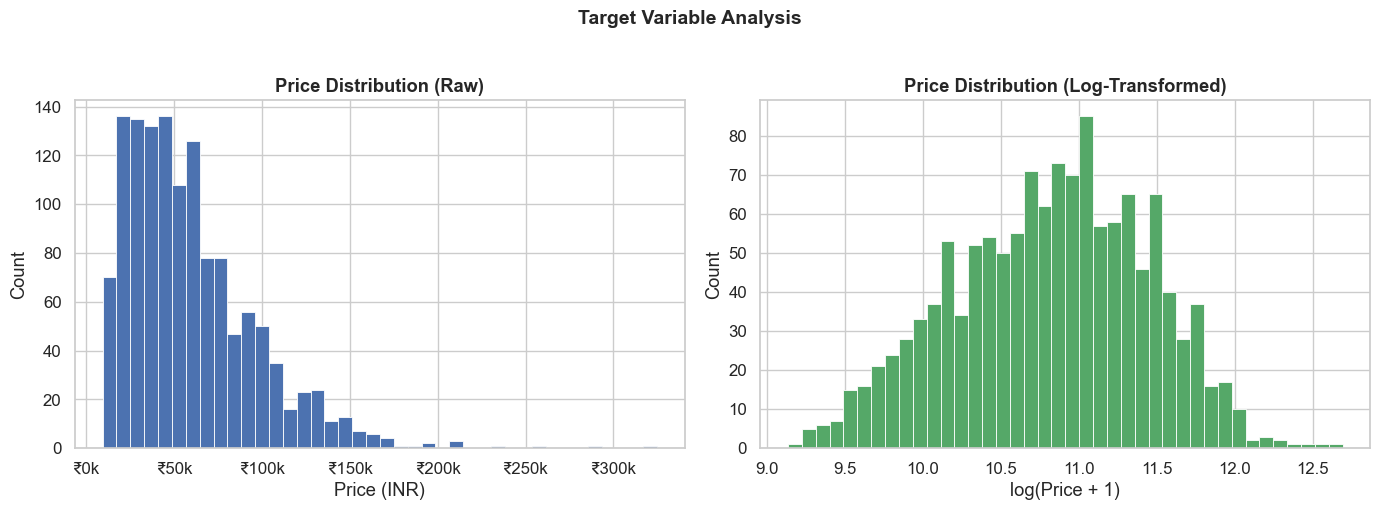


Price Statistics:
  Min    : ₹     9,271
  Median : ₹    52,108
  Mean   : ₹    59,889
  Max    : ₹   324,955


In [10]:
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

axes[0].hist(dataset['Price'], bins=40, color=ACCENT, edgecolor='white', linewidth=0.6)
axes[0].set_title('Price Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))

axes[1].hist(np.log1p(dataset['Price']), bins=40, color='#55A868', edgecolor='white', linewidth=0.6)
axes[1].set_title('Price Distribution (Log-Transformed)', fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nPrice Statistics:')
print(f'  Min    : ₹{dataset["Price"].min():>10,.0f}')
print(f'  Median : ₹{dataset["Price"].median():>10,.0f}')
print(f'  Mean   : ₹{dataset["Price"].mean():>10,.0f}')
print(f'  Max    : ₹{dataset["Price"].max():>10,.0f}')

### 4.2 — Price by Key Categorical Features

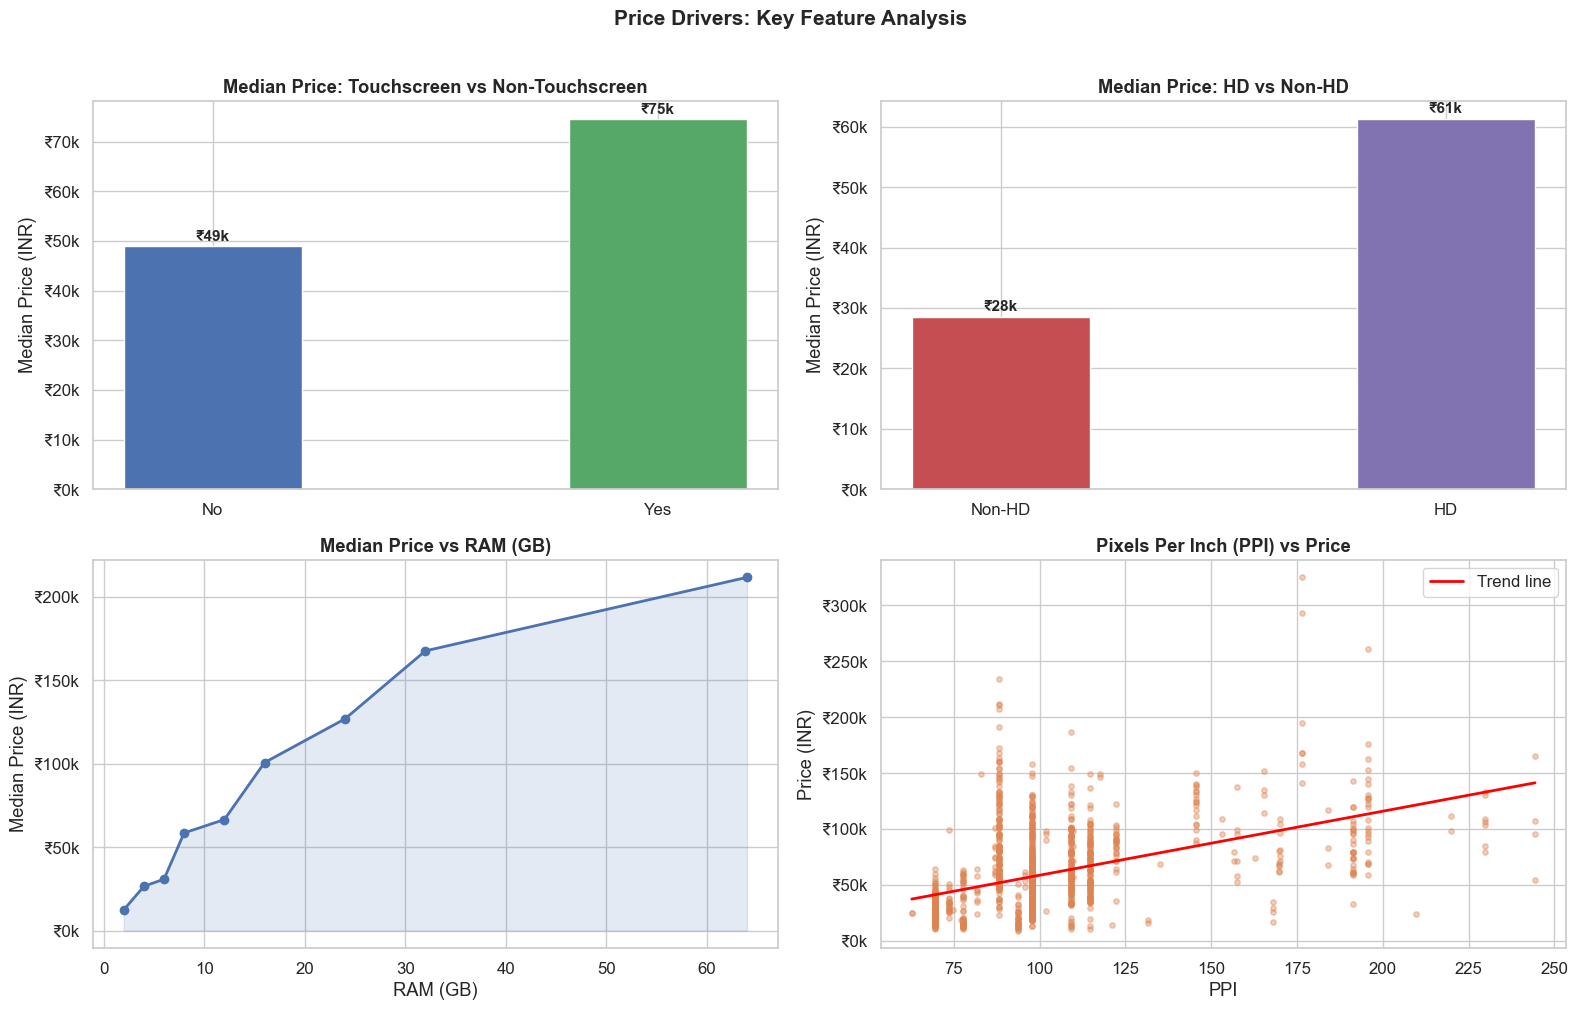

In [11]:
df_plot = dataset.copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

touch_df = df_plot.groupby('Touchscreen')['Price'].median().reset_index()
touch_df['Touchscreen'] = touch_df['Touchscreen'].map({0: 'No', 1: 'Yes'})
axes[0,0].bar(touch_df['Touchscreen'], touch_df['Price'], color=[ACCENT, '#55A868'], width=0.4)
axes[0,0].set_title('Median Price: Touchscreen vs Non-Touchscreen', fontweight='bold')
axes[0,0].set_ylabel('Median Price (INR)')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))
for bar in axes[0,0].patches:
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                   f'₹{bar.get_height()/1000:.0f}k', ha='center', fontsize=11, fontweight='bold')

hd_df = df_plot.groupby('HD')['Price'].median().reset_index()
hd_df['HD'] = hd_df['HD'].map({0: 'Non-HD', 1: 'HD'})
axes[0,1].bar(hd_df['HD'], hd_df['Price'], color=['#C44E52', '#8172B2'], width=0.4)
axes[0,1].set_title('Median Price: HD vs Non-HD', fontweight='bold')
axes[0,1].set_ylabel('Median Price (INR)')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))
for bar in axes[0,1].patches:
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                   f'₹{bar.get_height()/1000:.0f}k', ha='center', fontsize=11, fontweight='bold')

ram_df = df_plot.groupby('Ram')['Price'].median().sort_index()
axes[1,0].plot(ram_df.index, ram_df.values, marker='o', color=ACCENT, linewidth=2)
axes[1,0].fill_between(ram_df.index, ram_df.values, alpha=0.15, color=ACCENT)
axes[1,0].set_title('Median Price vs RAM (GB)', fontweight='bold')
axes[1,0].set_xlabel('RAM (GB)')
axes[1,0].set_ylabel('Median Price (INR)')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))

axes[1,1].scatter(df_plot['PPI'], df_plot['Price'], alpha=0.4, s=15, color='#DD8452')
m, b = np.polyfit(df_plot['PPI'], df_plot['Price'], 1)
x_line = np.linspace(df_plot['PPI'].min(), df_plot['PPI'].max(), 100)
axes[1,1].plot(x_line, m*x_line + b, color='red', linewidth=2, label='Trend line')
axes[1,1].set_title('Pixels Per Inch (PPI) vs Price', fontweight='bold')
axes[1,1].set_xlabel('PPI')
axes[1,1].set_ylabel('Price (INR)')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))
axes[1,1].legend()

plt.suptitle('Price Drivers: Key Feature Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 — Correlation Heatmap

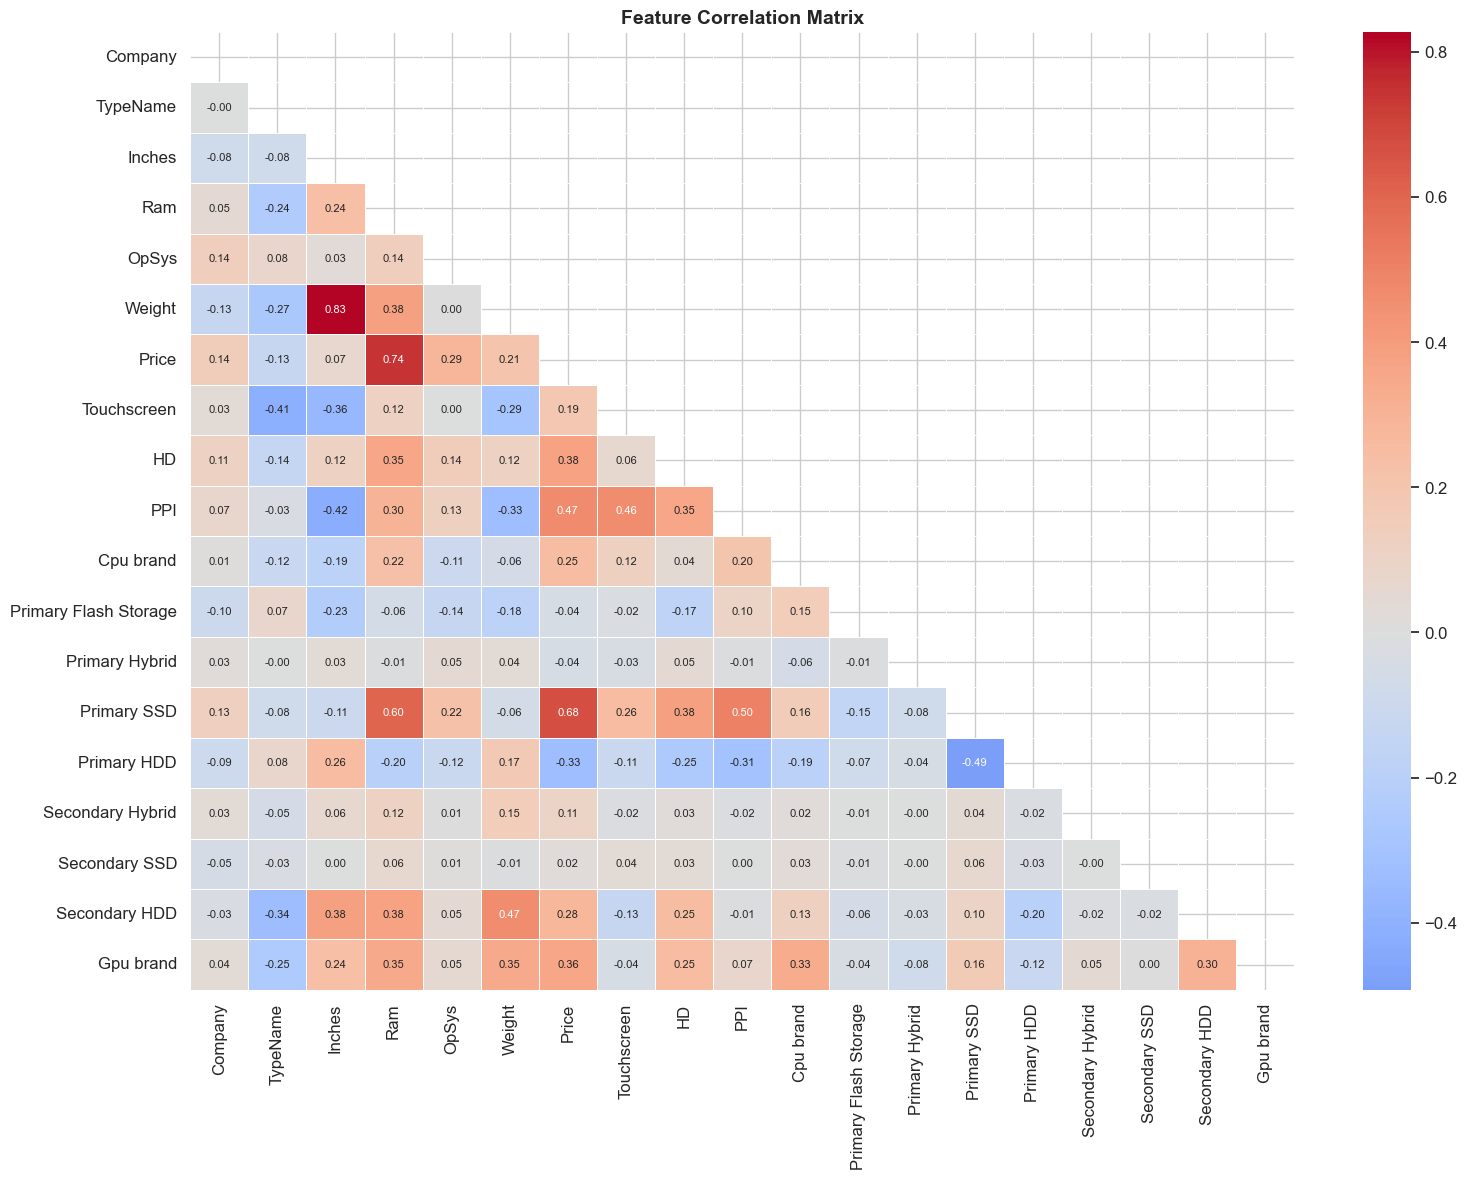


Top 10 Features Correlated with Price:
Ram              0.742905
Primary SSD      0.675849
PPI              0.469970
HD               0.376830
Gpu brand        0.355788
Primary HDD      0.330692
OpSys            0.288585
Secondary HDD    0.284460
Cpu brand        0.245597
Weight           0.209867


In [12]:
fig, ax = plt.subplots(figsize=(16, 12))
corr = dataset.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 Features Correlated with Price:')
print(corr['Price'].drop('Price').abs().sort_values(ascending=False).head(10).to_string())

### 4.4 — Storage Type Analysis

posx and posy should be finite values
posx and posy should be finite values


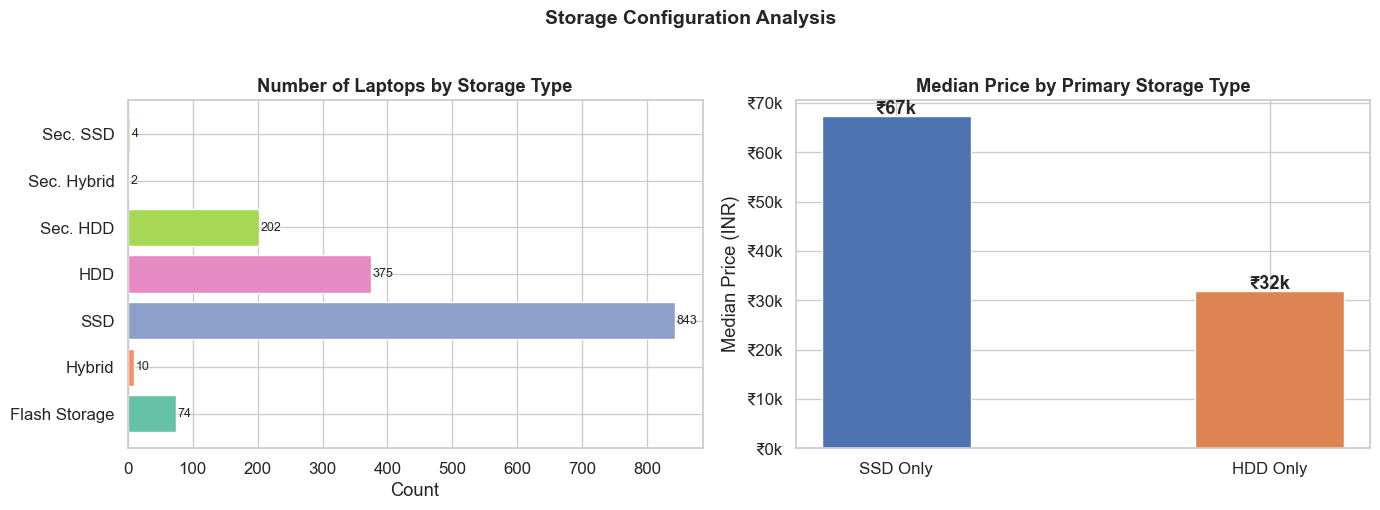

In [13]:
storage_cols = ['Primary Flash Storage', 'Primary Hybrid', 'Primary SSD', 'Primary HDD',
                'Secondary HDD', 'Secondary Hybrid', 'Secondary SSD']

storage_usage = {
    col.replace('Primary ', '').replace('Secondary ', 'Sec. '):
    (dataset[col] > 0).sum()
    for col in storage_cols
}

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

bars = axes[0].barh(list(storage_usage.keys()), list(storage_usage.values()),
                    color=sns.color_palette(PALETTE, len(storage_usage)))
axes[0].set_title('Number of Laptops by Storage Type', fontweight='bold')
axes[0].set_xlabel('Count')
for bar in bars:
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())), va='center', fontsize=9)

ssd_group  = dataset[dataset['Primary SSD'] > 0]['Price'].median()
hdd_group  = dataset[dataset['Primary HDD'] > 0]['Price'].median()
both_group = dataset[(dataset['Primary SSD'] > 0) & (dataset['Primary HDD'] > 0)]['Price'].median()

categories = ['SSD Only', 'HDD Only', 'SSD + HDD']
values     = [ssd_group, hdd_group, both_group]
colors     = ['#4C72B0', '#DD8452', '#55A868']

axes[1].bar(categories, values, color=colors, width=0.4)
axes[1].set_title('Median Price by Primary Storage Type', fontweight='bold')
axes[1].set_ylabel('Median Price (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))
for i, v in enumerate(values):
    axes[1].text(i, v + 500, f'₹{v/1000:.0f}k', ha='center', fontweight='bold')

plt.suptitle('Storage Configuration Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Stage 5 — Model Training & Benchmarking

### 5.1 — Train-Test Split & Scaling

In [14]:
X = dataset.drop(columns=['Price'])
y = dataset['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train samples : {X_train.shape[0]:,}')
print(f'Test  samples : {X_test.shape[0]:,}')
print(f'Features      : {X_train.shape[1]}')

Train samples : 1,041
Test  samples : 261
Features      : 18


### 5.2 — Define Model Zoo

In [15]:
rf_base   = RandomForestRegressor(n_estimators=350, random_state=3,
                                  max_samples=0.5, max_features=0.75,
                                  max_depth=15, bootstrap=True)
gbdt_base = GradientBoostingRegressor(n_estimators=100, max_features=0.5)
xgb_base  = XGBRegressor(n_estimators=25, learning_rate=0.3, max_depth=5,
                         verbosity=0)
et_base   = ExtraTreesRegressor(n_estimators=100, random_state=3,
                                max_samples=0.5, max_features=0.75,
                                max_depth=10, bootstrap=True)

MODELS = {
    'Linear Regression' : LinearRegression(),
    'Lasso'             : Lasso(),
    'Ridge'             : Ridge(),
    'ElasticNet'        : ElasticNet(),
    'Decision Tree'     : DecisionTreeRegressor(),
    'KNN'               : KNeighborsRegressor(n_neighbors=3),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=3,
                                                max_samples=0.5, max_features=0.75,
                                                max_depth=15),
    'Gradient Boost'    : GradientBoostingRegressor(n_estimators=500),
    'AdaBoost'          : AdaBoostRegressor(n_estimators=15, learning_rate=1.0),
    'XGBoost'           : XGBRegressor(n_estimators=45, max_depth=5,
                                       learning_rate=0.5, verbosity=0),
    'Voting Regressor'  : VotingRegressor([('rf', rf_base), ('gbdt', gbdt_base),
                                           ('xgb', xgb_base), ('et', et_base)],
                                          weights=[5, 1, 1, 1]),
    'Stacking Regressor': StackingRegressor(
        estimators=[('rf', rf_base), ('gbdt', gbdt_base), ('xgb', xgb_base)],
        final_estimator=Ridge(alpha=100)
    )
}

print(f'Models to benchmark: {len(MODELS)}')

Models to benchmark: 12


### 5.3 — Train & Evaluate All Models

In [16]:
results     = []
best_model  = None
best_r2     = float('-inf')

def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

print(f'{"Model":<22} {"R² Score":>10} {"RMSE":>12} {"MAE":>12}')
print('─' * 60)

for name, model in MODELS.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    mae, rmse, r2 = evaluate(y_test, y_pred)

    results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
    print(f'{name:<22} {r2:>10.4f} {rmse:>12,.0f} {mae:>12,.0f}')

    if r2 > best_r2:
        best_r2    = r2
        best_model = model
        best_name  = name

print('─' * 60)
print(f'\n Best Model: {best_name}  (R² = {best_r2:.4f})')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

Model                    R² Score         RMSE          MAE
────────────────────────────────────────────────────────────
Linear Regression          0.7021       20,631       15,377
Lasso                      0.7021       20,631       15,377
Ridge                      0.7021       20,632       15,378
ElasticNet                 0.6586       22,086       16,400
Decision Tree              0.7256       19,801       12,264


KNN                        0.7592       18,549       11,764
Random Forest              0.8029       16,780       10,429
Gradient Boost             0.8526       14,514        9,905
AdaBoost                   0.6862       21,174       17,030
XGBoost                    0.8597       14,158        9,617
Voting Regressor           0.8197       16,051       10,413
Stacking Regressor         0.8303       15,573       10,359
────────────────────────────────────────────────────────────

 Best Model: XGBoost  (R² = 0.8597)


### 5.4 — Model Comparison Visualisation

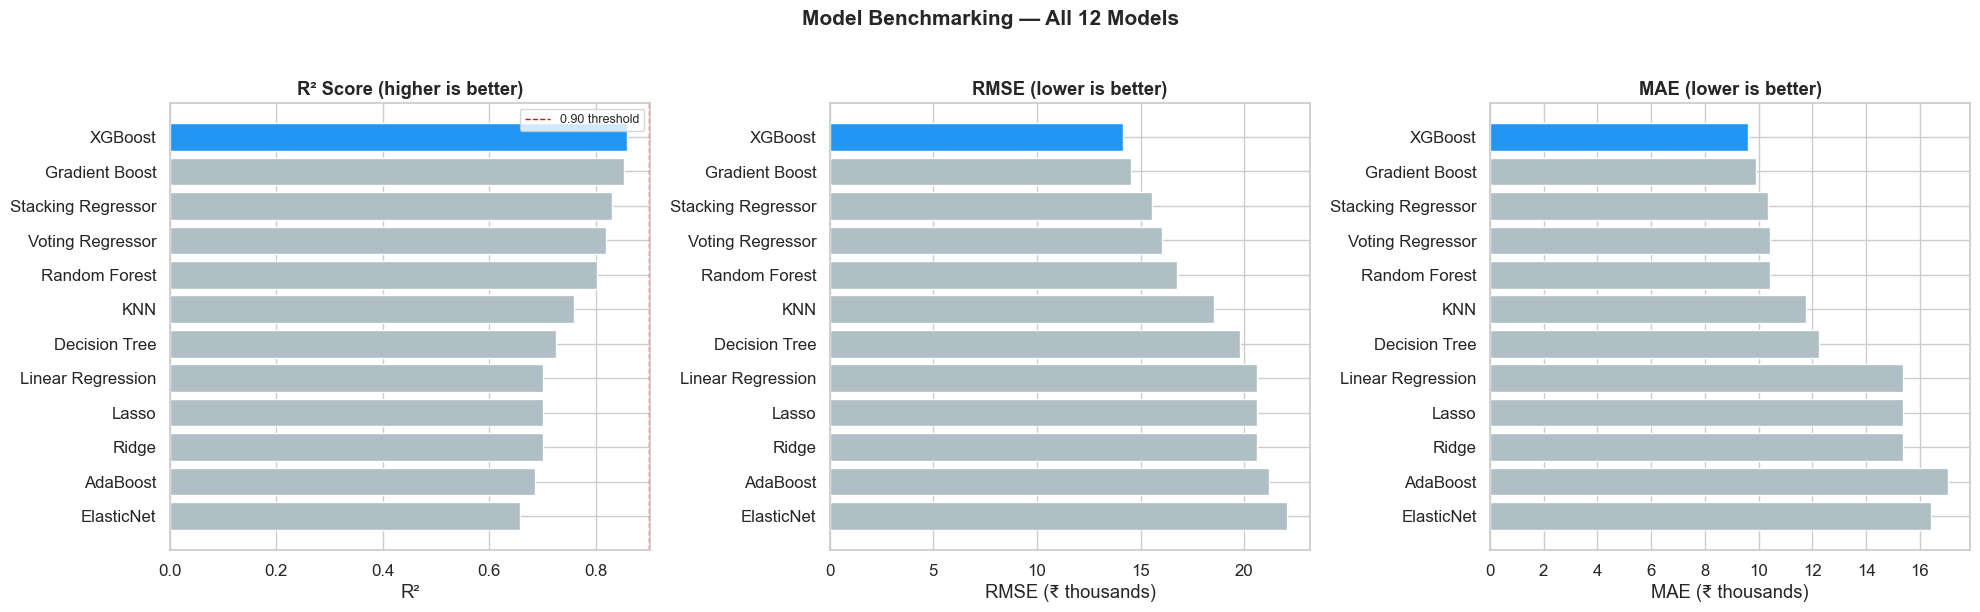

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = [('#2196F3' if i == 0 else '#B0BEC5') for i in range(len(results_df))]

axes[0].barh(results_df['Model'], results_df['R2'], color=colors)
axes[0].set_title('R² Score (higher is better)', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].invert_yaxis()
axes[0].axvline(0.9, color='red', linestyle='--', linewidth=1, label='0.90 threshold')
axes[0].legend(fontsize=9)

colors_r = list(reversed(colors))
axes[1].barh(results_df['Model'], results_df['RMSE'] / 1000, color=colors)
axes[1].set_title('RMSE (lower is better)', fontweight='bold')
axes[1].set_xlabel('RMSE (₹ thousands)')
axes[1].invert_yaxis()

axes[2].barh(results_df['Model'], results_df['MAE'] / 1000, color=colors)
axes[2].set_title('MAE (lower is better)', fontweight='bold')
axes[2].set_xlabel('MAE (₹ thousands)')
axes[2].invert_yaxis()

plt.suptitle('Model Benchmarking — All 12 Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.5 — Best Model: Predicted vs Actual

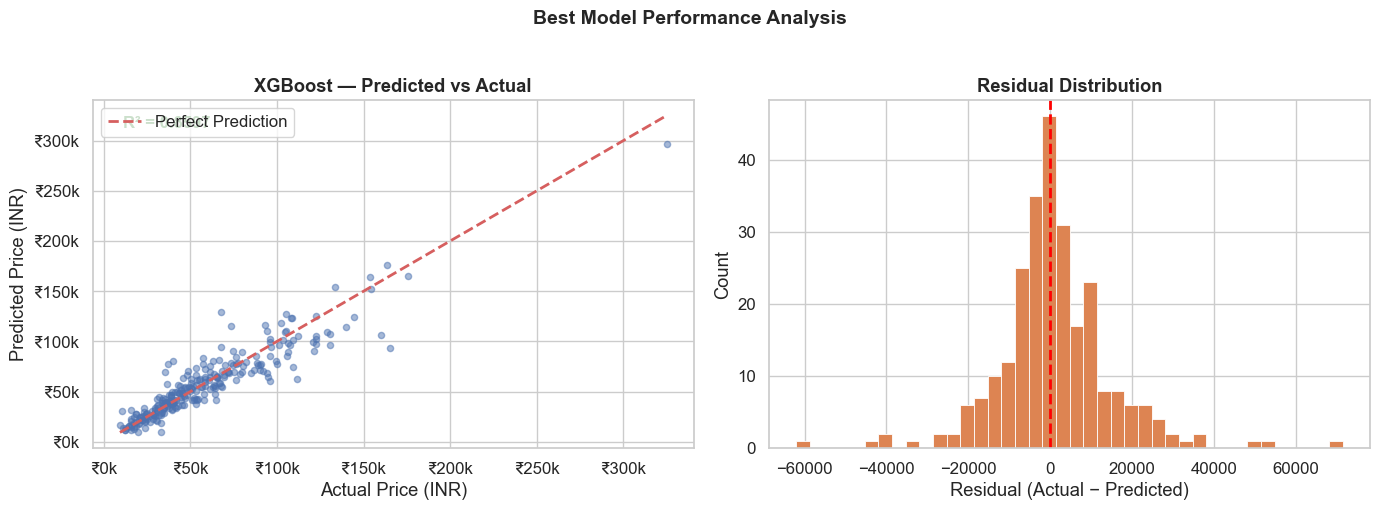

In [18]:
y_pred_best = best_model.predict(X_test_sc)
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=20, color=ACCENT)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'{best_name} — Predicted vs Actual', fontweight='bold')
axes[0].set_xlabel('Actual Price (INR)')
axes[0].set_ylabel('Predicted Price (INR)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {best_r2:.4f}', transform=axes[0].transAxes,
             fontsize=12, fontweight='bold', color='darkgreen')

axes[1].hist(residuals, bins=40, color='#DD8452', edgecolor='white', linewidth=0.6)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')

plt.suptitle('Best Model Performance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.6 — Feature Importance (Best Tree-Based Model)

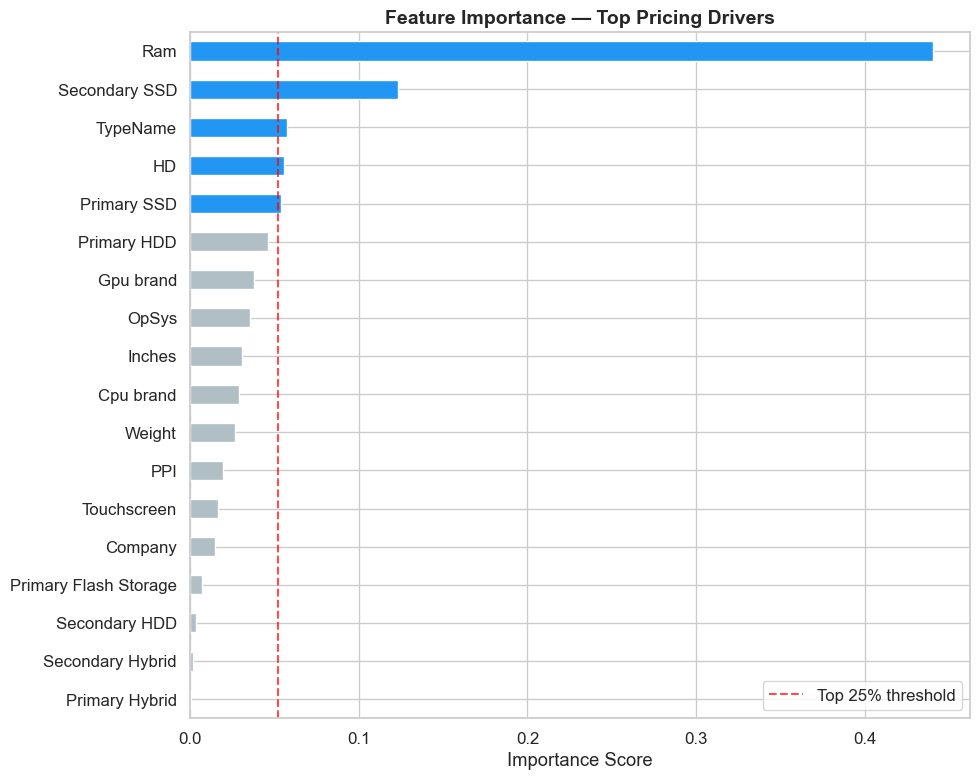


Top 5 Most Important Features:
  Ram                            0.4407
  Secondary SSD                  0.1232
  TypeName                       0.0575
  HD                             0.0553
  Primary SSD                    0.0539


In [19]:
def get_feature_importances(model):
    """Extract feature importances from the best model or one of its estimators."""
    if hasattr(model, 'feature_importances_'):
        return model.feature_importances_
    elif hasattr(model, 'estimators_'):            # Voting or Stacking
        for _, est in (model.estimators_ if hasattr(model.estimators_[0], '__len__') else [(None, e) for e in model.estimators_]):
            if hasattr(est, 'feature_importances_'):
                return est.feature_importances_
    return None

importances = get_feature_importances(best_model)

if importances is None:
    rf_fi = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_fi.fit(X_train_sc, y_train)
    importances = rf_fi.feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = ['#2196F3' if v >= feat_imp.quantile(0.75) else '#B0BEC5' for v in feat_imp]
feat_imp.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('Feature Importance — Top Pricing Drivers', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(feat_imp.quantile(0.75), color='red', linestyle='--', alpha=0.7, label='Top 25% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
for feat, score in feat_imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<30} {score:.4f}')

---
## Stage 6 — Model Export for Deployment

In [20]:
joblib.dump(best_model, 'models\Best_Model.pkl')

joblib.dump(dataset, 'models\dataset.pkl')

cat_cols = ['Company', 'TypeName', 'OpSys', 'Cpu brand', 'Gpu brand']
fitted_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(dataset[col])
    fitted_encoders[col] = le

df_orig = pd.read_csv('data\laptop_data.csv')
df_orig.drop(columns=[c for c in df_orig.columns if 'Unnamed' in c], inplace=True)

def categorise_cpu(cpu_str):
    name = ' '.join(cpu_str.split()[:3])
    if name in ('Intel Core i7', 'Intel Core i5', 'Intel Core i3'):
        return name
    elif cpu_str.split()[0] == 'Intel':
        return 'Other Intel Processor'
    else:
        return 'AMD Processor'

df_orig['Cpu brand'] = df_orig['Cpu'].apply(categorise_cpu)
df_orig['Gpu brand'] = df_orig['Gpu'].apply(lambda x: x.split()[0])
df_orig = df_orig[df_orig['Gpu brand'] != 'ARM']

encoder_cols = {
    'Company'  : df_orig['Company'],
    'TypeName' : df_orig['TypeName'],
    'OpSys'    : df_orig['OpSys'],
    'Cpu brand': df_orig['Cpu brand'],
    'Gpu brand': df_orig['Gpu brand'],
}

saved_encoders = {}
for col, series in encoder_cols.items():
    le = LabelEncoder()
    le.fit(series)
    saved_encoders[col] = le
    print(f'  {col:<12}: {list(le.classes_)}')

joblib.dump(saved_encoders, 'models\encoders.pkl')

print('Model saved   → Best_Model.pkl')
print('Encoders saved → encoders.pkl  (use in Streamlit app for named dropdowns)')
print('Dataset saved  → dataset.pkl')
print(f'Best model R² on hold-out test set: {best_r2:.4f}')

  Company     : ['Acer', 'Apple', 'Asus', 'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero', 'Xiaomi']
  TypeName    : ['2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook', 'Ultrabook', 'Workstation']
  OpSys       : ['Android', 'Chrome OS', 'Linux', 'Mac OS X', 'No OS', 'Windows 10', 'Windows 10 S', 'Windows 7', 'macOS']
  Cpu brand   : ['AMD Processor', 'Intel Core i3', 'Intel Core i5', 'Intel Core i7', 'Other Intel Processor']
  Gpu brand   : ['AMD', 'Intel', 'Nvidia']
Model saved   → Best_Model.pkl
Encoders saved → encoders.pkl  (use in Streamlit app for named dropdowns)
Dataset saved  → dataset.pkl
Best model R² on hold-out test set: 0.8597
